# Problem Set 10 — Inferring cosmology from the Planck CMB spectrum with NPE

**Starter notebook.** The background and the full task descriptions are on the worksheet
(`ProblemSet10_2026.pdf`). This notebook gives you the data loader, the prior, and the plotting
helpers; you fill in the tasks (`# TODO`).

We infer the matter and baryon densities $(\Omega_m, \Omega_b)$ around their fiducial Planck 2018
values $\Omega_m = 0.3153 \pm 0.0073$, $\Omega_b = 0.0494 \pm 0.0003$ (i.e.
$\Omega_b h^2 = 0.02238 \pm 0.00015$). The $\pm$ values are the Planck 2018 $1\sigma$ errors, and
the uniform prior spans $\pm 4\sigma$ around the fiducial. All other parameters are held fixed:
$H_0 = 67.32$ km/s/Mpc, $n_s = 0.9661$, $\ln(10^{10}A_s) = 3.045$, $\tau = 0.0543$.

The CAMB simulations are shipped in `planck_camb_tt.h5`, so you do **not** need CAMB
installed — the loader is provided. Reference: the NPE recipe in `lecture_10_NPE.ipynb`. (If you
do have CAMB and want to rebuild the data, run `python make_planck_npe_data.py`.)

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import torch
import scipy

from sbi.inference import NPE
from sbi.utils import BoxUniform
from sbi.diagnostics import run_sbc, check_sbc

from make_planck_npe_data import load_planck_npe_data

%matplotlib inline
torch.set_default_dtype(torch.float32)
torch.manual_seed(7)
rng = np.random.default_rng(7)

theta_labels = [r"$\Omega_m$", r"$\Omega_b$"]
print("setup ok")

setup ok


## 1. Load the simulations  *(Task 1)*

Load the training bank from `planck_camb_tt.h5` and set up the prior. The file holds
`theta` $=(\Omega_m,\Omega_b)$ and the corresponding **clean** (noise-free) CAMB spectra
`spectra`, plus the multipoles `ell`, the fiducial cosmology, and the Planck observation
(used later). *This cell is provided.*

In [ ]:
data = load_planck_npe_data()

theta = torch.as_tensor(data.theta, dtype=torch.float32)        # (n, 2)
spectra = torch.as_tensor(data.spectra, dtype=torch.float32)    # (n, n_ell), CLEAN
ell = data.ell
fid_theta = data.fid_theta
fid_spectrum = data.fid_spectrum

prior = BoxUniform(low=torch.as_tensor(data.prior_low, dtype=torch.float32),
                   high=torch.as_tensor(data.prior_high, dtype=torch.float32))

n_sims, n_features = spectra.shape
print(f"{n_sims} simulations, {n_features} multipoles, ell in [{ell.min():.0f}, {ell.max():.0f}]")
print("prior low :", np.asarray(data.prior_low))
print("prior high:", np.asarray(data.prior_high))
print("fiducial  :", fid_theta)

2000 simulations, 1499 multipoles, ell in [2, 1500]
prior low : [0.2861     0.04806506]
prior high: [0.3445     0.05071291]
fiducial  : [0.3153     0.04938898]


## 2. Plot the prior-predictive spectra  *(Task 2)*

Plot a random sample (~40) of the clean training spectra and overlay the fiducial spectrum, to
see how much the spectrum moves as $(\Omega_m,\Omega_b)$ vary across the prior.

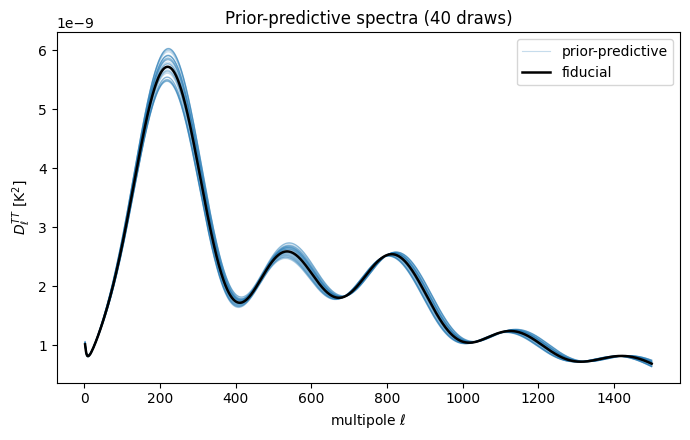

In [3]:
# Task 2: plot ~40 prior-predictive spectra (light blue) and overlay the fiducial (black).
# Hint: idx = rng.choice(n_sims, size=40, replace=False); loop ax.plot(ell, spectra[j].numpy(), ...)
#       then ax.plot(ell, fid_spectrum, "k-", label="fiducial").
fig, ax = plt.subplots(figsize=(7, 4.5))
idx = rng.choice(n_sims, size=40, replace=False)
for i,j in enumerate(idx):
    if i == 0:
        ax.plot(ell, spectra[j].numpy(), color="tab:blue", alpha=0.25, lw=0.8, label="prior-predictive")
    else:
        ax.plot(ell, spectra[j].numpy(), color="tab:blue", alpha=0.25, lw=0.8)
ax.plot(ell, fid_spectrum, "k-", lw=1.8, label="fiducial")
ax.set_xlabel(r"multipole $\ell$")
ax.set_ylabel(r"$D_\ell^{TT}$ [K$^2$]")
ax.set_title("Prior-predictive spectra (40 draws)")
ax.legend()
plt.tight_layout()

## 3. Load the Planck data  *(Task 3)*

Extract the official unbinned Planck TT observation from `data` and plot it with its error bars,
together with the fiducial CAMB spectrum. You will infer the cosmology from exactly this data
vector in Task 6.

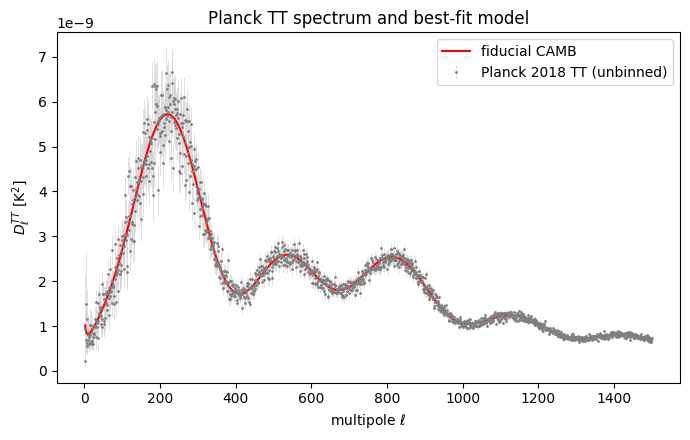

In [4]:
# Task 3: pull the Planck observation from `data` and plot it with error bars.
# Assign these (used again in Tasks 4, 6, 7):
#   planck_dl, planck_err_minus, planck_err_plus, planck_sigma  =  data.<...>
# Hint: ax.errorbar(ell, planck_dl, yerr=[planck_err_minus, planck_err_plus], fmt=".")
planck_dl = data.planck_dl
planck_err_minus = data.planck_err_minus
planck_err_plus  = data.planck_err_plus
planck_sigma     = data.planck_sigma

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(ell, planck_dl, yerr=[planck_err_minus, planck_err_plus],
            fmt=".", ms=2, color="gray", ecolor="lightgray", elinewidth=0.5,
            label="Planck 2018 TT (unbinned)")
ax.plot(ell, fid_spectrum, "r-", lw=1.5, label="fiducial CAMB")
ax.set_xlabel(r"multipole $\ell$"); ax.set_ylabel(r"$D_\ell^{TT}$ [K$^2$]")
ax.set_title("Planck TT spectrum and best-fit model")
ax.legend()
plt.tight_layout()

## 4. Add measurement errors — cosmic variance  *(Task 4)*

The shipped spectra are **noise-free**. Build a diagonal noise model and apply it to every training
spectrum, so the network learns from data that look like the real, noisy Planck observation.

The per-multipole variance is cosmic variance (which **scales with the spectrum**, Knox formula)
plus a fixed instrument floor:

$$\sigma_\ell^2(\theta) = \underbrace{\frac{2}{(2\ell+1)\,f_{\rm sky}}\,D_\ell(\theta)^2}_{\text{cosmic variance}} + \sigma_{{\rm floor},\ell}^2 .$$

Calibrate the floor **once** so the fiducial cosmology reproduces the Planck error bars:
$\sigma_{{\rm floor},\ell}^2 = \max\!\big(\sigma_\ell^{\rm Planck\,2} - \sigma_{\rm cv}(D_\ell^{\rm fid})^2,\,0\big)$.
Then standardize the features $(x-\mu)/\sigma$ before training.

In [5]:
# Task 4: build the measurement-noise model and apply it to the CLEAN spectra.
#  (a) cosmic_variance_sigma(D_ell) = sqrt(2/((2*ell+1)*F_SKY)) * D_ell           (Knox formula)
#  (b) sigma_floor (fixed): calibrate so the FIDUCIAL total error matches Planck:
#         sigma_floor^2 = clip(planck_sigma^2 - cosmic_variance_sigma(fid_spectrum)^2, 0, None)
#  (c) add_noise(clean): draw Normal(0, sqrt(sigma_cv(clean)^2 + sigma_floor^2)) and add it
#  (d) x_all = standardized (x - mean) / std of the noised spectra
#  Also define standardize(dl) so you can reuse mu/sigma on the Planck vector in Task 6.
F_SKY = 1.0

def cosmic_variance_sigma(dl, ell):
    return np.sqrt(2.0 / ((2 * ell + 1) * F_SKY)) * dl

# Calibrate the floor once, using the fiducial spectrum
cv_fid = cosmic_variance_sigma(fid_spectrum, ell)
sigma_floor2 = np.clip(planck_sigma**2 - cv_fid**2, 0.0, None)

def add_noise(clean, rng_):
    cv = cosmic_variance_sigma(clean, ell)              # depends on THIS theta's spectrum
    sigma_tot = np.sqrt(cv**2 + sigma_floor2[None, :])
    return clean + rng_.normal(0.0, sigma_tot)

spectra_np = spectra.numpy()
noised = add_noise(spectra_np, rng)

mu, sigma_data = noised.mean(axis=0), noised.std(axis=0)

def standardize(dl):
    return (dl - mu) / sigma_data

x_all = torch.as_tensor(standardize(noised), dtype=torch.float32)
print("x_all\nmean:", x_all.mean().item(),"\nstd:", x_all.std().item())

x_all
mean: 0.0 
std: 1.0000001192092896


## 5. Train the NPE  *(Task 5)*

Train an amortized NPE, exactly as in `lecture_10_NPE.ipynb` §2:
`NPE(prior)` → `append_simulations(theta, x).train()` → `build_posterior(...)`.
Hold out the **last `n_test = 300`** simulations — you will use them for the coverage test in Task 7.

In [6]:
# Task 5: train an amortized NPE (mirror lecture_10_NPE.ipynb section 2).
#   inference = NPE(prior=prior)
#   inference.append_simulations(theta_train, x_train).train(max_num_epochs=120)
#   posterior = inference.build_posterior(...)
# Hold out the LAST n_test=300 simulations for the coverage check in Task 7:
#   theta_train, x_train = theta[:-n_test], x_all[:-n_test]
n_test = 300

theta_train, x_train = theta[:-n_test], x_all[:-n_test]
theta_test,  x_test   = theta[-n_test:], x_all[-n_test:]   # held out for Task 7

inference = NPE(prior=prior)
estimator = inference.append_simulations(theta_train, x_train).train(max_num_epochs=120)
posterior = inference.build_posterior(estimator)

 Neural network successfully converged after 25 epochs.

## 6. Posterior for the Planck spectrum  *(Task 6)*

Plotting helpers are provided below (2-D credible contours + 1-D marginals, with an optional
truth marker and error bars). *This cell is provided — just run it.*

In [7]:
from scipy.ndimage import gaussian_filter

def credible_levels_from_samples(samples, bins=80, masses=(0.95, 0.68)):
    H, xe, ye = np.histogram2d(samples[:, 0], samples[:, 1], bins=bins, density=True)
    H = gaussian_filter(H.T, sigma=1.2)
    dx, dy = xe[1] - xe[0], ye[1] - ye[0]
    flat = np.sort(H.ravel())[::-1]
    csum = np.cumsum(flat) * dx * dy
    levels = sorted(flat[min(np.searchsorted(csum, m), len(flat) - 1)] for m in masses)
    xc, yc = 0.5 * (xe[:-1] + xe[1:]), 0.5 * (ye[:-1] + ye[1:])
    X, Y = np.meshgrid(xc, yc)
    return X, Y, H, levels

def draw_posterior(samples, truth=None, truth_err=None, title="Posterior"):
    samples = np.asarray(samples)
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    X, Y, H, levels = credible_levels_from_samples(samples)
    axes[0].contour(X, Y, H, levels=levels, colors=["tab:blue", "navy"], linewidths=[1.2, 1.8])
    axes[0].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.03, color="tab:blue", rasterized=True)
    if truth is not None:
        if truth_err is not None:
            axes[0].errorbar(truth[0], truth[1], xerr=truth_err[0], yerr=truth_err[1],
                             fmt="r*", ms=13, ecolor="r", capsize=3, label="Planck 2018")
        else:
            axes[0].plot(truth[0], truth[1], "r*", ms=13, label="fiducial")
        axes[0].legend(fontsize=8)
    axes[0].set_xlabel(theta_labels[0]); axes[0].set_ylabel(theta_labels[1]); axes[0].set_title(title)
    for j, ax in enumerate(axes[1:]):
        ax.hist(samples[:, j], bins=60, density=True, color="tab:blue", alpha=0.65)
        if truth is not None:
            ax.axvline(truth[j], color="r", ls=":", lw=2)
            if truth_err is not None:
                ax.axvspan(truth[j] - truth_err[j], truth[j] + truth_err[j], color="r", alpha=0.12)
        ax.set_xlabel(theta_labels[j]); ax.set_ylabel("density")
    plt.tight_layout()
    return fig, axes

Now sample the posterior at the Planck data vector and plot it. Mark the Planck 2018 fiducial
with its published 1-$\sigma$ error bars. Does the contour cover the fiducial?

(<Figure size 1200x360 with 3 Axes>,
 array([<Axes: title={'center': 'Posterior'}, xlabel='$\\Omega_m$', ylabel='$\\Omega_b$'>,
        <Axes: xlabel='$\\Omega_m$', ylabel='density'>,
        <Axes: xlabel='$\\Omega_b$', ylabel='density'>], dtype=object))

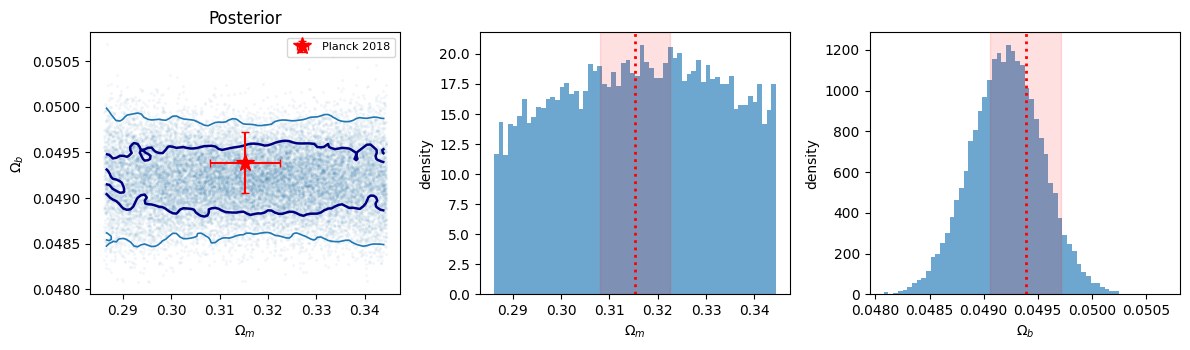

In [8]:
# Task 6: sample the posterior at the Planck data vector and plot it with draw_posterior().
# Mark the Planck 2018 fiducial with its 1-sigma error bars:
#   omega_b_sigma = 0.00015 / data.h**2 ; truth_err = [0.0073, omega_b_sigma]
# Hint: x_planck = standardize(planck_dl).reshape(1, -1)
#       planck_samples = posterior.sample((20000,), x=x_planck, show_progress_bars=False).numpy()
x_planck = torch.as_tensor(standardize(planck_dl), dtype=torch.float32).reshape(1, -1)
planck_samples = posterior.sample((20000,), x=x_planck, show_progress_bars=False).numpy()

omega_b_sigma = 0.00015 / data.h**2
truth, truth_err = fid_theta, [0.0073, omega_b_sigma]

draw_posterior(planck_samples, truth=truth, truth_err=truth_err, )

## 7. Checks — coverage & posterior predictive  *(Task 7)*

A neural posterior *always* returns an answer; these checks ask whether to trust it.

**(a) Coverage / SBC.** On the held-out simulations (`theta[-n_test:]`, `x_all[-n_test:]`), run
simulation-based calibration: rank each true value among posterior draws. Flat rank histograms =
calibrated; $\cup$-shaped = overconfident.

**(b) Posterior-predictive check (PPC) — _optional_.** Draw parameters from the Planck posterior
and look at the spectra they imply — they should straddle the Planck data. Without CAMB at
inference time, approximate the simulator by the **nearest pre-computed training spectrum**
(`scipy.spatial.cKDTree`). *(With CAMB you would resimulate exactly via
`make_planck_npe_data.camb_tt_spectrum`.)*

In [9]:
# Task 7a (coverage / SBC): use the held-out sims theta[-n_test:], x_all[-n_test:].
# Hint: ranks, dap = run_sbc(theta_sbc, x_sbc, posterior, num_posterior_samples=200)
#       ks = check_sbc(ranks, theta_sbc, dap, num_posterior_samples=200)["ks_pvals"]
#       then plot rank histograms (15 bins, range (0,200)); flat = calibrated.

from sbi.diagnostics import run_sbc, check_sbc

ranks, dap = run_sbc(theta_test, x_test, posterior, num_posterior_samples=200)
res = check_sbc(ranks, theta_test, dap, num_posterior_samples=200)
print("KS p-values:", res["ks_pvals"])

Drawing 200 samples for 300 observations: 207it [00:03, 56.13it/s]                         
Calculating ranks for 300 SBC samples: 100%|██████████| 300/300 [00:00<00:00, 47497.03it/s]


KS p-values: tensor([0.0207, 0.6591])


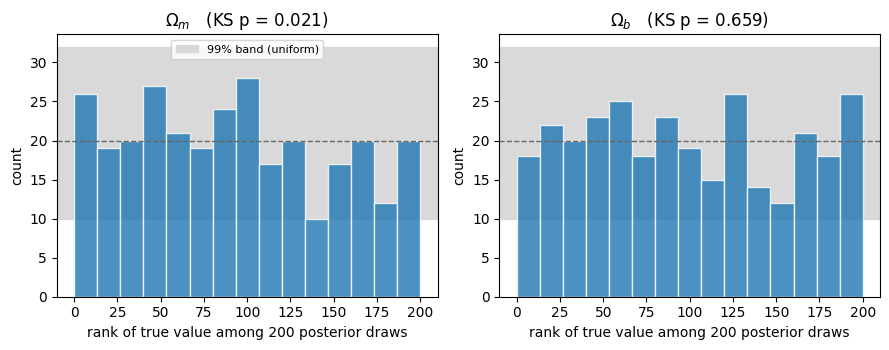

In [14]:
N = theta_test.shape[0]
nbins = 15
L = 200

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for j, ax in enumerate(axes):
    expected = N / nbins
    lo, hi = scipy.stats.binom.interval(0.99, N, 1.0 / nbins)        # central 99% band per bin
    ax.axhspan(lo, hi, color="0.85", label="99% band (uniform)")
    ax.axhline(expected, color="0.4", ls="--", lw=1.0)
    ax.hist(ranks[:, j].numpy(), bins=nbins, range=(0, L),
            color="tab:blue", alpha=0.8, edgecolor="white")
    ax.set_title(f"{theta_labels[j]}   (KS p = {res['ks_pvals'][j]:.3f})")
    ax.set_xlabel(f"rank of true value among {L} posterior draws")
    ax.set_ylabel("count")
    if j == 0:
        ax.legend(fontsize=8, loc="upper center")
plt.tight_layout()

In [ ]:
# Task 7b (OPTIONAL — PPC): draw ~60 parameters from the Planck posterior; for each, use the
# nearest training spectrum as a stand-in simulator, and overlay these on the Planck data.
# Hint: from scipy.spatial import cKDTree; tree = cKDTree(theta.numpy())
#       ppc_theta = posterior.sample((60,), x=x_planck, ...).numpy(); _, nn = tree.query(ppc_theta)
raise NotImplementedError("Task 7b (optional): posterior-predictive check")